# **Importing Libraries**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Loaded the dataset**

In [10]:
df = pd.read_csv('finaldataset.csv')

In [12]:
df = df.drop(columns=["Code"])

In [14]:
print(df.shape)
print(df.info())
print(df.head())

(200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Entity                                  200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Total population                        200 non-null    int64  
 3   Coastal population                      200 non-null    int64  
 4   Coastal population density(/km^2)       200 non-null    float64
 5   % mismanaged from total regional waste  200 non-null    float64
 6   Mismanaged waste(tonnes)                200 non-null    int64  
 7   Oceans plastic leakage (y)              200 non-null    float64
dtypes: float64(3), int64(4), object(1)
memory usage: 12.6+ KB
None
                 Entity  Year  Total population  Coastal population  \
0  Americas (excl. USA)  2000         239839213           

# **Set X (features) and y (target)**

In [17]:
y = df["Oceans plastic leakage (y)"]

In [19]:
X = df.drop(columns=["Oceans plastic leakage (y)", "Entity"])

# **Train test split**

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **RandomForestRegressor**

In [27]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [29]:
y_pred = model.predict(X_test)

In [31]:
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print(comparison)


         Actual     Predicted
0     854925.00  9.120195e+05
1    3308621.00  3.145070e+06
2    4171954.00  3.982889e+06
3    2771924.00  2.602278e+06
4      12853.00  1.259760e+04
5    1465308.00  1.393085e+06
6    3398072.00  3.374202e+06
7    2409952.00  2.386847e+06
8    2823467.00  2.872291e+06
9    1191053.00  1.167615e+06
10   2937352.00  2.707231e+06
11   9881777.00  1.014966e+07
12   1920488.00  1.882971e+06
13   4881724.00  4.777010e+06
14  13285542.00  1.282926e+07
15   3139809.00  3.182235e+06
16   3166844.00  3.082533e+06
17   1742369.00  1.749296e+06
18    202382.00  2.064075e+05
19   3241914.00  3.138438e+06
20      8940.00  8.438870e+03
21   3522357.00  3.445548e+06
22   1236532.00  1.327030e+06
23    705267.00  8.423269e+05
24   2789810.00  2.574969e+06
25   2108221.00  2.231850e+06
26    261945.02  2.749464e+05
27   3088272.00  2.829226e+06
28      9811.00  1.010971e+04
29     17973.00  3.231979e+04
30   2207340.00  2.179873e+06
31   3974368.00  3.825544e+06
32   29374

# **Comaparison between Actual and Predicted values**

In [40]:
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
comparison['Predicted'] = comparison['Predicted'].round(2)
print(comparison.to_string())

         Actual    Predicted
0     854925.00    912019.48
1    3308621.00   3145069.85
2    4171954.00   3982889.43
3    2771924.00   2602277.86
4      12853.00     12597.60
5    1465308.00   1393085.10
6    3398072.00   3374201.71
7    2409952.00   2386846.99
8    2823467.00   2872290.94
9    1191053.00   1167614.98
10   2937352.00   2707231.08
11   9881777.00  10149659.61
12   1920488.00   1882970.51
13   4881724.00   4777010.28
14  13285542.00  12829260.48
15   3139809.00   3182234.84
16   3166844.00   3082532.79
17   1742369.00   1749295.83
18    202382.00    206407.54
19   3241914.00   3138437.71
20      8940.00      8438.87
21   3522357.00   3445548.48
22   1236532.00   1327029.71
23    705267.00    842326.91
24   2789810.00   2574969.15
25   2108221.00   2231850.07
26    261945.02    274946.39
27   3088272.00   2829225.78
28      9811.00     10109.71
29     17973.00     32319.79
30   2207340.00   2179872.58
31   3974368.00   3825544.01
32   2937417.00   2817090.97
33   4377486.0

# **Actual v/s Predicted values graph**

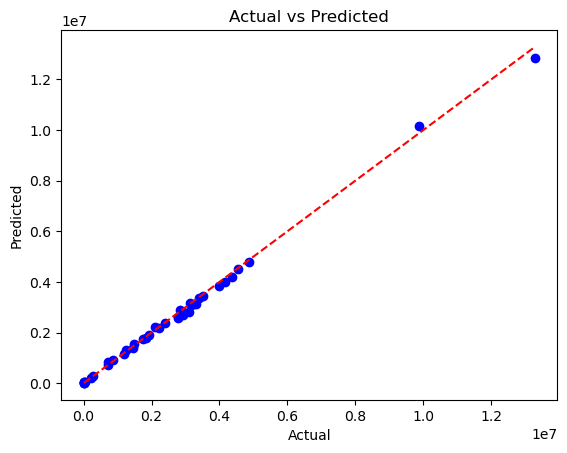

In [33]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# **MSE and R2 score**

In [35]:
from sklearn.metrics import mean_squared_error, r2_score

In [37]:
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("MSE :", mse)
print("R2  :", r2)


MSE : 17946042504.972977
R2  : 0.9972103924429768


# **Checked Overfitting**

In [40]:
r2_train = r2_score(y_train, model.predict(X_train))
r2_test  = r2_score(y_test, y_pred)

print("Train R2 :", r2_train)
print("Test  R2 :", r2_test)



Train R2 : 0.9995320563389558
Test  R2 : 0.9972103924429768


The model does not overfit because the difference between Train R2 (0.9995) and Test R2 (0.9975) is only 0.002, which is very small, meaning the model performs equally well on both seen and unseen data.

### **Feature Importance**

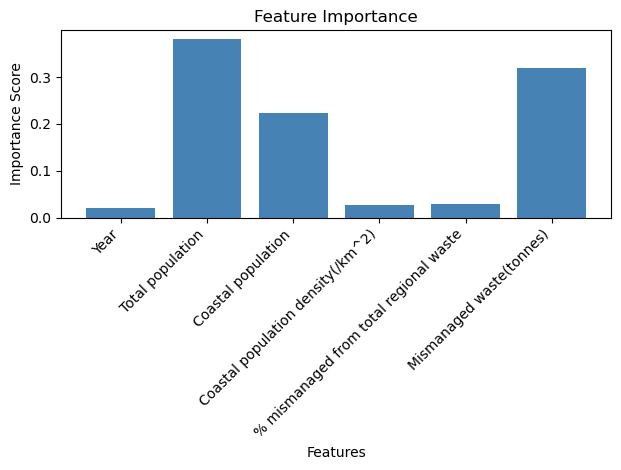

In [44]:
features = X.columns
importance = model.feature_importances_

plt.bar(features, importance, color='steelblue')
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This graph shows which feature has the most influence in predicting ocean plastic leakage.

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [48]:
print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R2: 0.9746307868197134


In [49]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Final Test R2:", r2_score(y_test, y_pred))
print("Final RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Final Test R2: 0.997564454712539
Final RMSE: 125173.06752330925


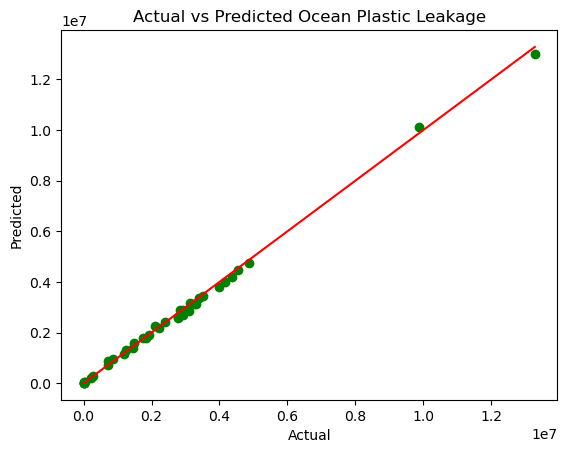

In [50]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred, color='green')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Ocean Plastic Leakage")
plt.show()